#  분류란?

## (1) 지도학습중: 회귀 vs 분류

지도학습에는 연속적인 숫자값을 예측하는 **회귀(Regression)**와, 데이터를 주어진 항목으로 나누는 **분류(Classification)**가 있음.

- **회귀**: 주어진 데이터(X)로 정답(Y)을 잘 맞추는 함수를 찾는 문제
  
- **분류**: 기존 데이터가 어떤 레이블에 속하는지 패턴을 학습한 뒤, 새 데이터의 레이블을 판별
  

**그냥 예측하고자 하는 값(종속변수)이 연속형이면 회귀, 범주형이면 분류.**

## (2) 이진 분류와 다중 분류

- **이진 분류**: 예측 변수가 참/거짓 두개의 값만 가질 때
- **다중 분류**: 예측 변수가 가질 수 있는 값이 3개 이상일 때


#  분류 모델 4가지

## (1) 로지스틱 회귀 

이진 분류 문제를 푸는 대표 알고리즘. 샘플이 특정 클래스에 속할 확률을 추정해 기준치에 따라 분류.

> 독립 변수의 선형 조합(선형 회귀)에 로지스틱 함수를 적용해, 출력값을 0~1 사이로 변환하는 것.

**왜 필요? 단순 선형 회귀로 이진 분류를 풀 수 없는 이유**
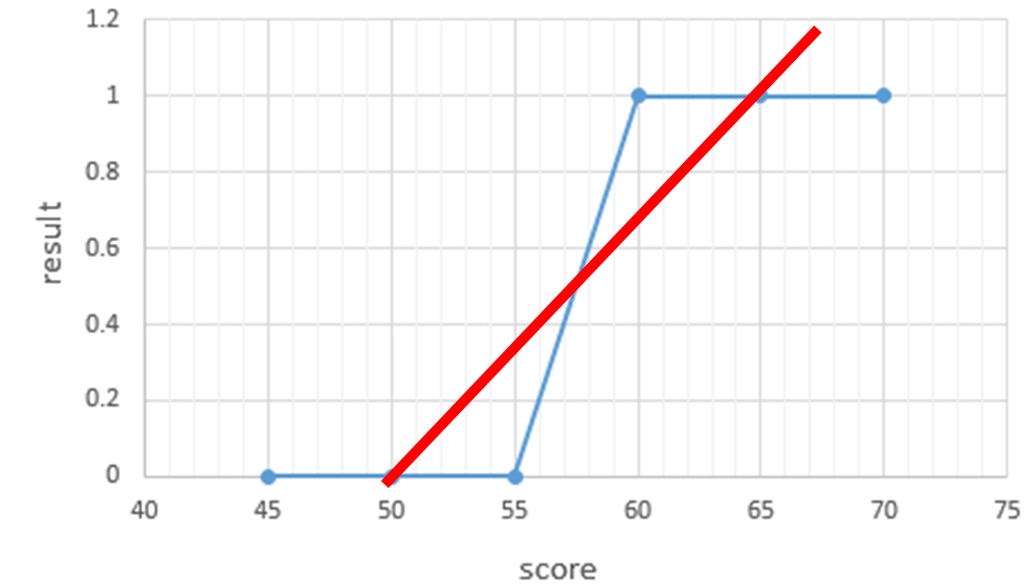
 x-y 관계는 직선이 아니라 **S자 형태** 함수로 표현해야함. 시그모이드 함수는 입력값이 작거나 클 때 천천히 변하고 중간값 근처에서 급격히 변해서, 양 끝에서 포화되어 노이즈에 안정적임.

→ **출력이 0과 1 사이면서 S자 형태인 함수가 필요**

**시그모이드 함수(≈ 로지스틱 함수)**: 출력이 0~1 사이 값을 가지며 S자 형태로 그려지는 함수
- 특징: 입력값이 커지면 1에 수렴, 작아지면 0에 수렴. 입력 x가 (-∞, ∞)일 때 출력 y는 0~1 (밑에 그래프 참고)
- → 출력값이 특정값 이상이면 1, 이하면 0으로 이진 분류
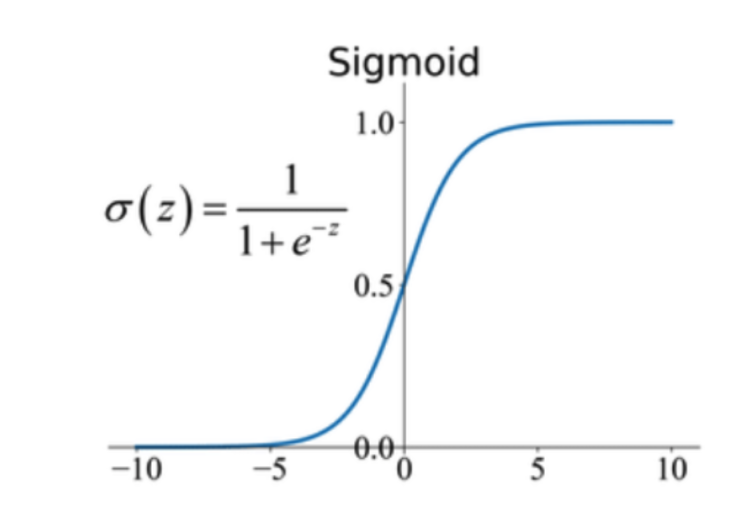

```python
def sigmoid(x):
    return 1/(1+np.exp(-x))
```

**시그모이드 함수의 가중치**: $H(x)=\frac{1}{1+e^{-(wx+b)}}=sigmoid(wx+b)=\sigma(wx+b)$ — 인공지능은 데이터에 적합한 가중치 $w$, $b$를 계산해서 찾음.
- $w$ 변화 → 그래프 기울기 변화
- $b$ 변화 → 그래프 위치 좌우로의 변화

(참고) 승산(오즈)과 로짓
- 승산(오즈): $odds=\frac{p(A)}{1-p(A)}$ — 사건이 일어날 확률이 일어나지 않을 확률보다 몇 배 높은지. 

- logit 함수(odds의 로그 변환): $z=logit(p)=log(\frac{p(A)}{1-p(A)})$
- $p(A)=\frac{1}{1+e^{-(wx+b)}}$의 양변에 logit을 적용하면 $logit(p)=wx+b$ → ***로짓 함수는 로지스틱 회귀 모델이 확률을 선형 관계로 변환***

## (2) 의사결정나무 
조건에 따라 데이터를 분류, 즉 스무고개와 비슷. 층 내 동질성은 커지고 층 간 이질성은 커지는 방향으로 가지뻗어나감.
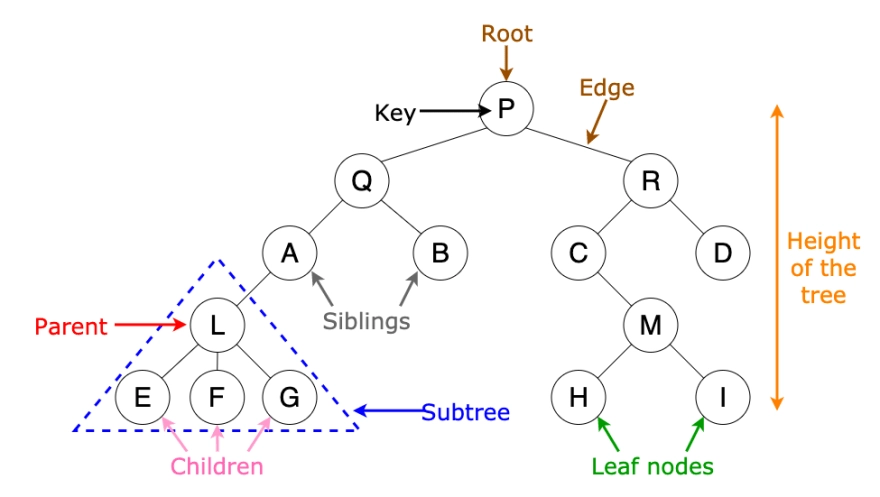

**구성 요소**
- Root Node: 가장 상위 노드
- Parent Node: 주어진 노드의 상위 노드
- Child Node: 하나의 노드에서 분리된 2개 이상 노드
- Binary Tree: children이 최대 2개인 tree
- Leaf Nodes: 자식마디 없는 노드, label에 해당
- Edge: Parent-child 연결선
- Height: 특정 노드에서 가장 먼 leaf node까지 edge 개수
- Depth: Root node에서 특정 노드까지 도달하는 edge 수

**CART 알고리즘**: 데이터셋을 임계값 기준으로 두 child로 나누는, 가장 널리 쓰이는 의사결정나무 알고리즘. 임계값은 **불순도(지니 계수)가 낮아지는 방향**으로 나눔.

- 불순도?: 분류하려는 데이터 집합에서 서로 다른 클래스가 섞여 있는 정도. CART는 "지니 지수"로 확인.
- 지니 지수?: $Gini=1-\sum_{i=1}^n{P_i}^2$ ($P_i$는 class i의 비율), 0~1 사이 값
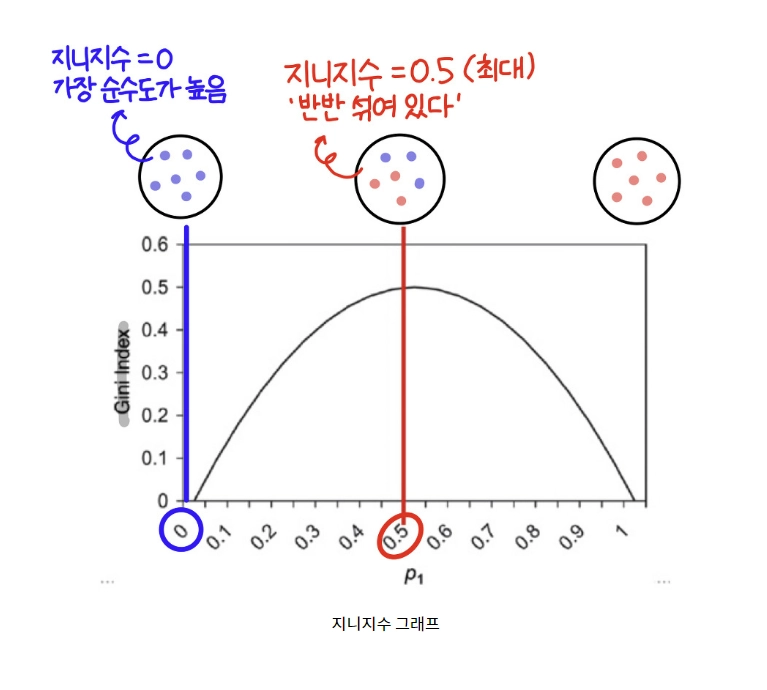
  - CART는 Gini불순도 값이 작아지는 방향으로 학습

**CART 주요 단계**: ① 임계값 설정 ② 불순도 감소 알고리즘
**실제 학습 시 고려사항**
- Hyperparameter: `min_samples_split`(분할되기 위한 노드의 최소 샘플 수), `min_samples_leaf`(리프 노드의 최소 샘플 수), `min_weight_fraction_leaf`(가중치 부여된 비율 버전), `max_leaf_nodes`(리프 노드 최대 개수), `max_features`(분할에 쓸 특성 최대 수)
- 시각화: 시각화를 수행함으로써 분류가 잘 이루어졌는지 확인할 수 있음.
- 가지치기: 불필요한 노드 지우기. 노드가 너무 많으면 과적합 확률이 높아지므로, 하부 트리를 제거.

## (3) SVM 
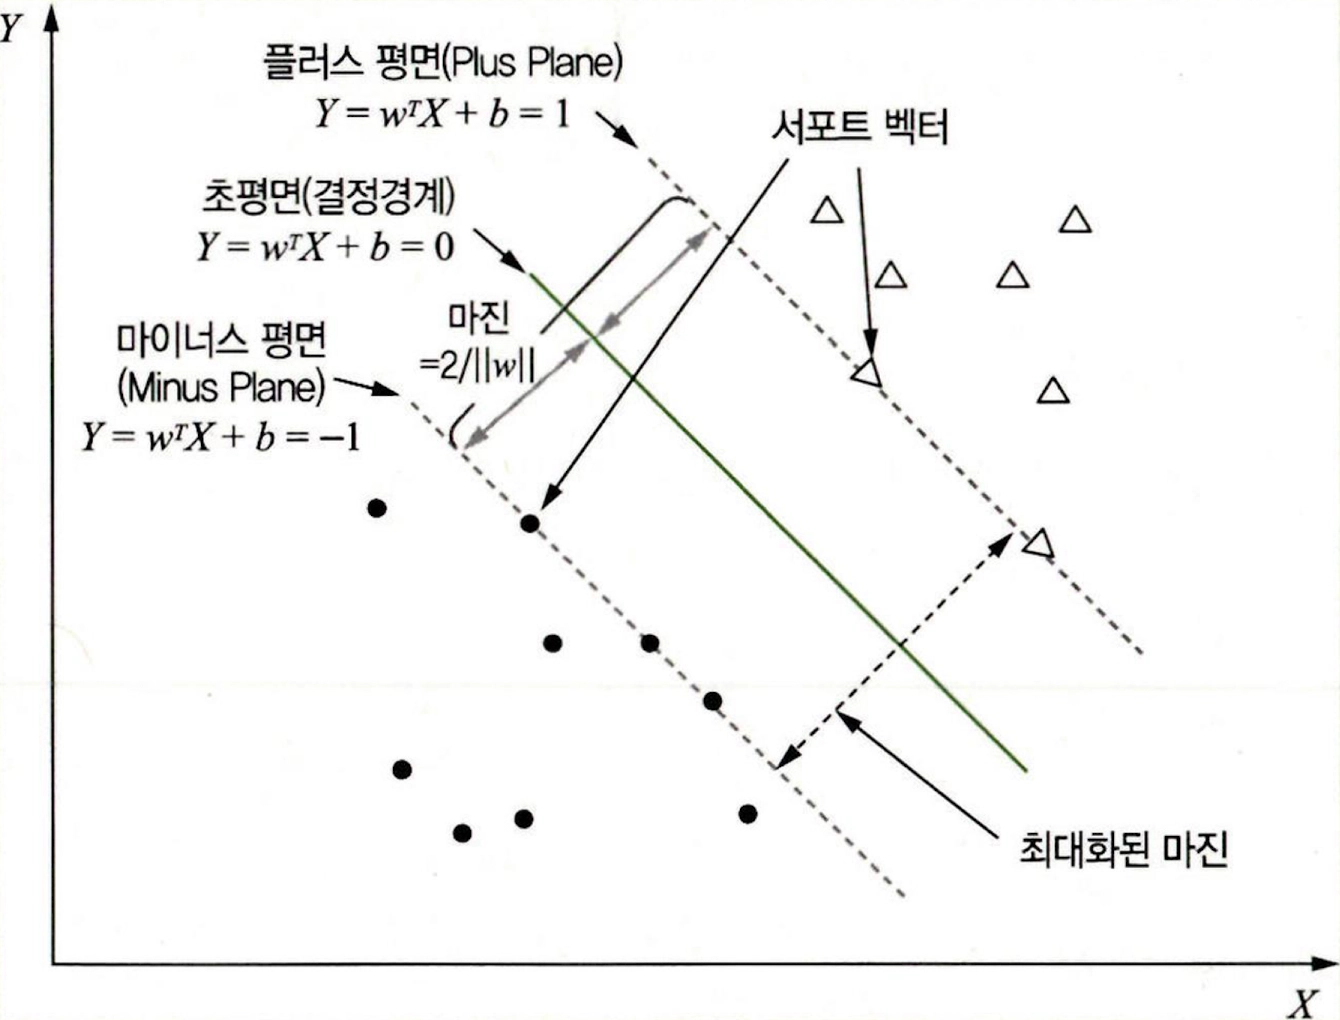

> 클래스를 분류할 수 있는 다양한 경계선 중 최적의 라인이 뭐냐?

**구성**
- Support vector: 결정 경계와 가장 가까운 데이터들의 집합
- Decision Boundary: 분류 기준이 되는 경계
- Margin: 결정 경계에서 서포트 벡터까지의 거리
- Hyperplane: n차원 공간의 (n-1)차원 평면
- Slack Variables: 완벽한 분리가 불가능할 때 허용된 오차 변수

**최적의 선 찾는 법**: **Margin이 가장 큰 경우**를 선택하면 됨. (f보다 제가 그린게 더 마진크지않나요?!)
#  분류란?

## (1) 지도학습중: 회귀 vs 분류

지도학습에는 연속적인 숫자값을 예측하는 **회귀(Regression)**와, 데이터를 주어진 항목으로 나누는 **분류(Classification)**가 있음.

- **회귀**: 주어진 데이터(X)로 정답(Y)을 잘 맞추는 함수를 찾는 문제
  
- **분류**: 기존 데이터가 어떤 레이블에 속하는지 패턴을 학습한 뒤, 새 데이터의 레이블을 판별
  

**그냥 예측하고자 하는 값(종속변수)이 연속형이면 회귀, 범주형이면 분류.**

## (2) 이진 분류와 다중 분류

- **이진 분류**: 예측 변수가 참/거짓 두개의 값만 가질 때
- **다중 분류**: 예측 변수가 가질 수 있는 값이 3개 이상일 때


#  분류 모델 4가지

## (1) 로지스틱 회귀 

이진 분류 문제를 푸는 대표 알고리즘. 샘플이 특정 클래스에 속할 확률을 추정해 기준치에 따라 분류.

> 독립 변수의 선형 조합(선형 회귀)에 로지스틱 함수를 적용해, 출력값을 0~1 사이로 변환하는 것.

**왜 필요? 단순 선형 회귀로 이진 분류를 풀 수 없는 이유**
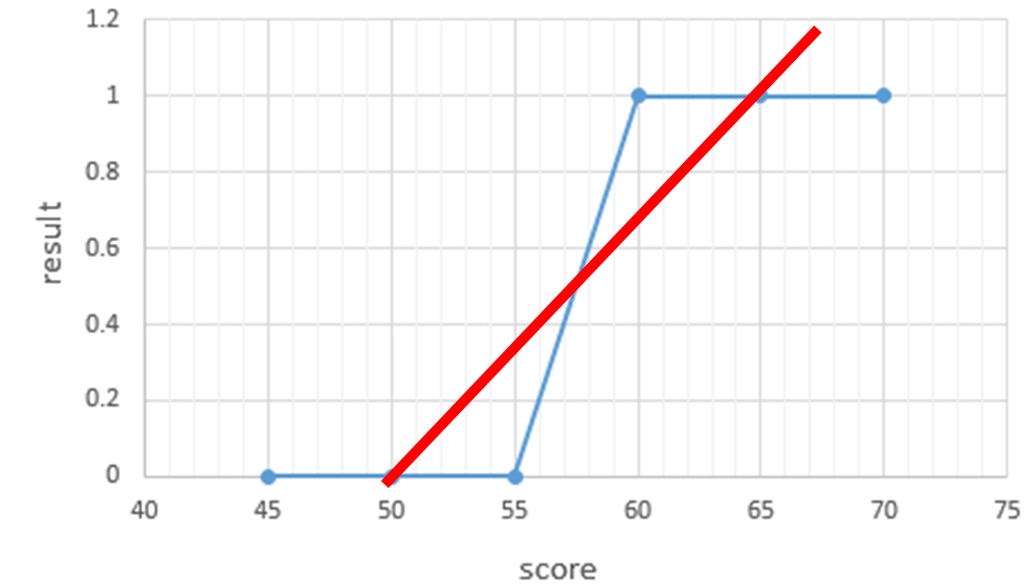
 x-y 관계는 직선이 아니라 **S자 형태** 함수로 표현해야함. 시그모이드 함수는 입력값이 작거나 클 때 천천히 변하고 중간값 근처에서 급격히 변해서, 양 끝에서 포화되어 노이즈에 안정적임.

→ **출력이 0과 1 사이면서 S자 형태인 함수가 필요**

**시그모이드 함수(≈ 로지스틱 함수)**: 출력이 0~1 사이 값을 가지며 S자 형태로 그려지는 함수
- 특징: 입력값이 커지면 1에 수렴, 작아지면 0에 수렴. 입력 x가 (-∞, ∞)일 때 출력 y는 0~1 (밑에 그래프 참고)
- → 출력값이 특정값 이상이면 1, 이하면 0으로 이진 분류
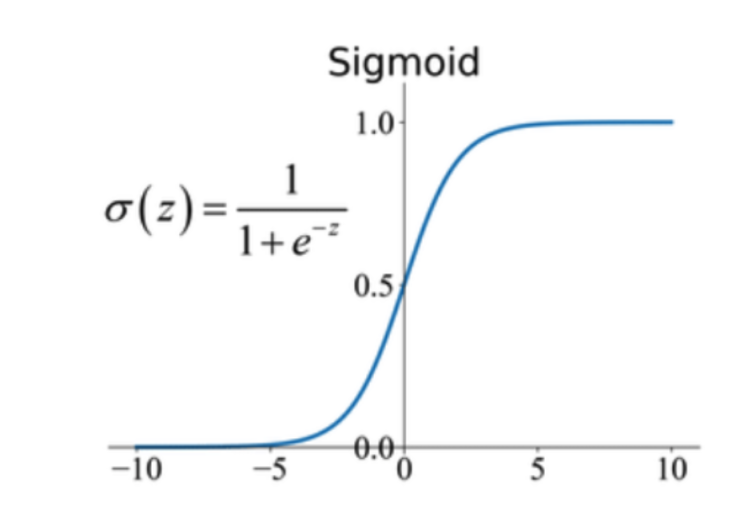

```python
def sigmoid(x):
    return 1/(1+np.exp(-x))
```

**시그모이드 함수의 가중치**: $H(x)=\frac{1}{1+e^{-(wx+b)}}=sigmoid(wx+b)=\sigma(wx+b)$ — 인공지능은 데이터에 적합한 가중치 $w$, $b$를 계산해서 찾음.
- $w$ 변화 → 그래프 기울기 변화
- $b$ 변화 → 그래프 위치 좌우로의 변화

(참고) 승산(오즈)과 로짓
- 승산(오즈): $odds=\frac{p(A)}{1-p(A)}$ — 사건이 일어날 확률이 일어나지 않을 확률보다 몇 배 높은지. 

- logit 함수(odds의 로그 변환): $z=logit(p)=log(\frac{p(A)}{1-p(A)})$
- $p(A)=\frac{1}{1+e^{-(wx+b)}}$의 양변에 logit을 적용하면 $logit(p)=wx+b$ → ***로짓 함수는 로지스틱 회귀 모델이 확률을 선형 관계로 변환***

## (2) 의사결정나무 
조건에 따라 데이터를 분류, 즉 스무고개와 비슷. 층 내 동질성은 커지고 층 간 이질성은 커지는 방향으로 가지뻗어나감.
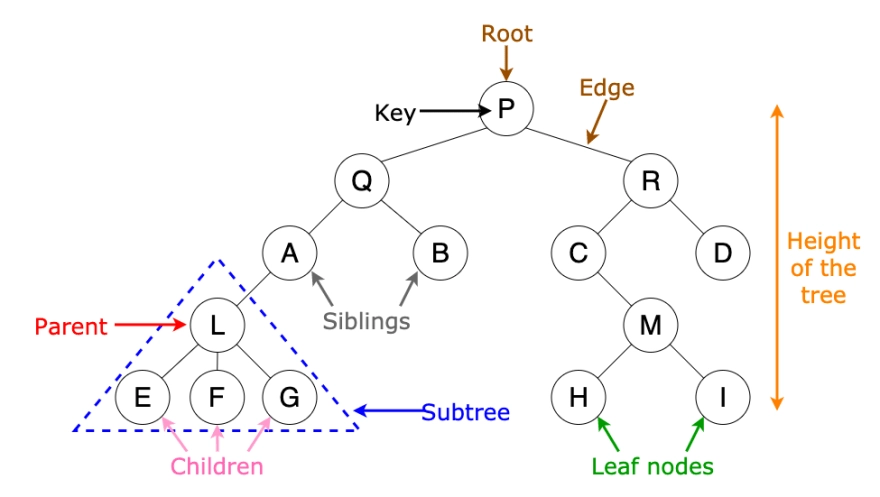

**구성 요소**
- Root Node: 가장 상위 노드
- Parent Node: 주어진 노드의 상위 노드
- Child Node: 하나의 노드에서 분리된 2개 이상 노드
- Binary Tree: children이 최대 2개인 tree
- Leaf Nodes: 자식마디 없는 노드, label에 해당
- Edge: Parent-child 연결선
- Height: 특정 노드에서 가장 먼 leaf node까지 edge 개수
- Depth: Root node에서 특정 노드까지 도달하는 edge 수

**CART 알고리즘**: 데이터셋을 임계값 기준으로 두 child로 나누는, 가장 널리 쓰이는 의사결정나무 알고리즘. 임계값은 **불순도(지니 계수)가 낮아지는 방향**으로 나눔.

- 불순도?: 분류하려는 데이터 집합에서 서로 다른 클래스가 섞여 있는 정도. CART는 "지니 지수"로 확인.
- 지니 지수?: $Gini=1-\sum_{i=1}^n{P_i}^2$ ($P_i$는 class i의 비율), 0~1 사이 값
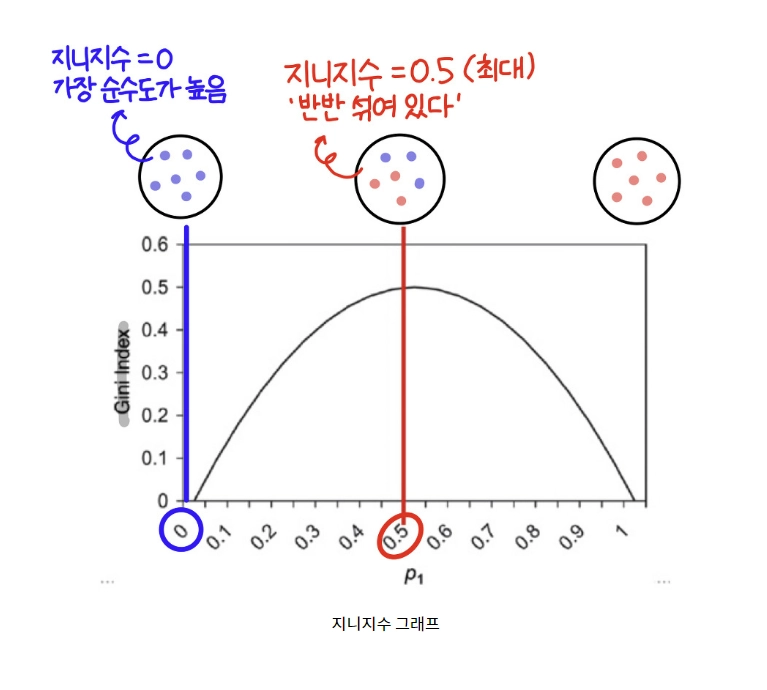
  - CART는 Gini불순도 값이 작아지는 방향으로 학습

**CART 주요 단계**: ① 임계값 설정 ② 불순도 감소 알고리즘
**실제 학습 시 고려사항**
- Hyperparameter: `min_samples_split`(분할되기 위한 노드의 최소 샘플 수), `min_samples_leaf`(리프 노드의 최소 샘플 수), `min_weight_fraction_leaf`(가중치 부여된 비율 버전), `max_leaf_nodes`(리프 노드 최대 개수), `max_features`(분할에 쓸 특성 최대 수)
- 시각화: 시각화를 수행함으로써 분류가 잘 이루어졌는지 확인할 수 있음.
- 가지치기: 불필요한 노드 지우기. 노드가 너무 많으면 과적합 확률이 높아지므로, 하부 트리를 제거.

## (3) SVM 
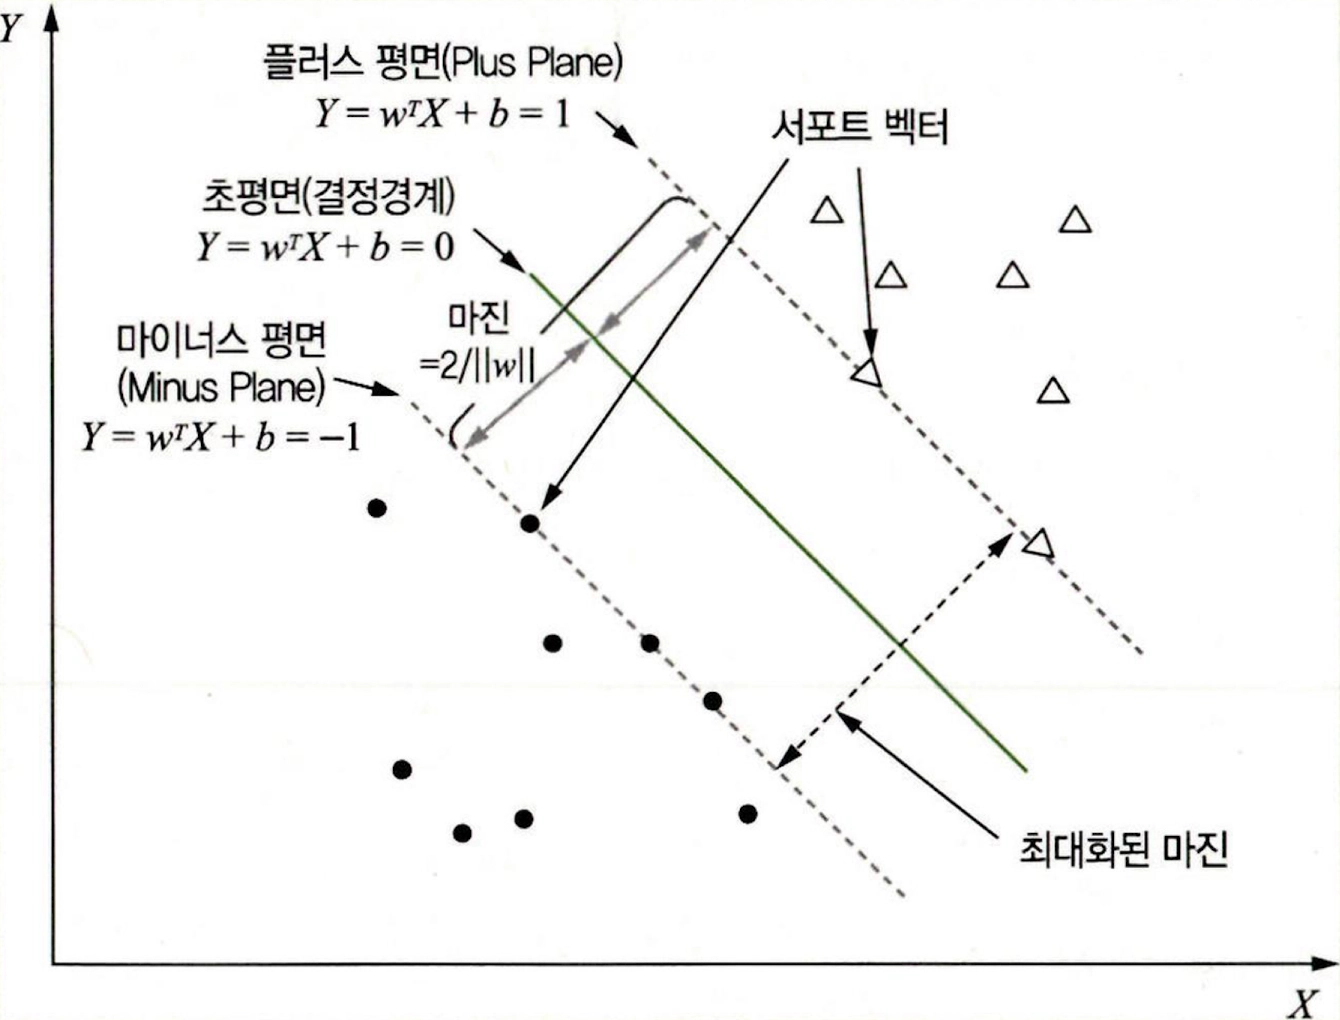

> 클래스를 분류할 수 있는 다양한 경계선 중 최적의 라인이 뭐냐?

**구성**
- Support vector: 결정 경계와 가장 가까운 데이터들의 집합
- Decision Boundary: 분류 기준이 되는 경계
- Margin: 결정 경계에서 서포트 벡터까지의 거리
- Hyperplane: n차원 공간의 (n-1)차원 평면
- Slack Variables: 완벽한 분리가 불가능할 때 허용된 오차 변수

**최적의 선 찾는 법**: **Margin이 가장 큰 경우**를 선택하면 됨. (f보다 제가 그린게 더 마진크지않나요?!)
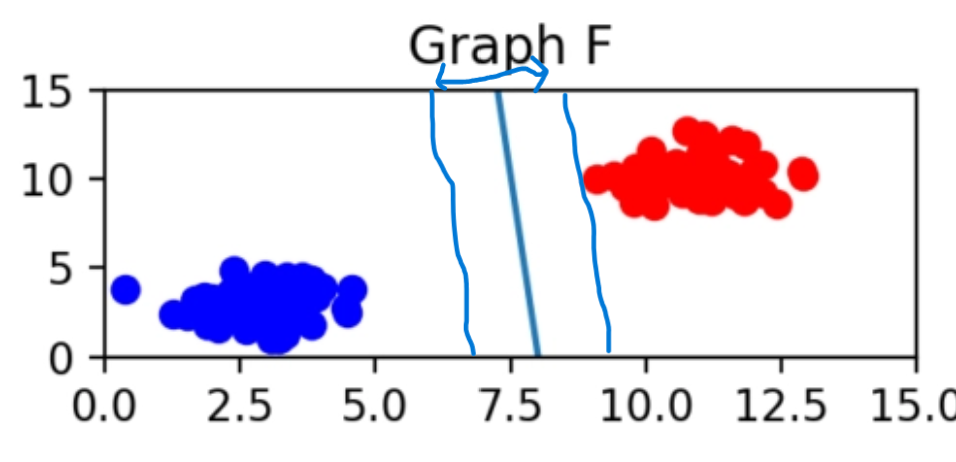
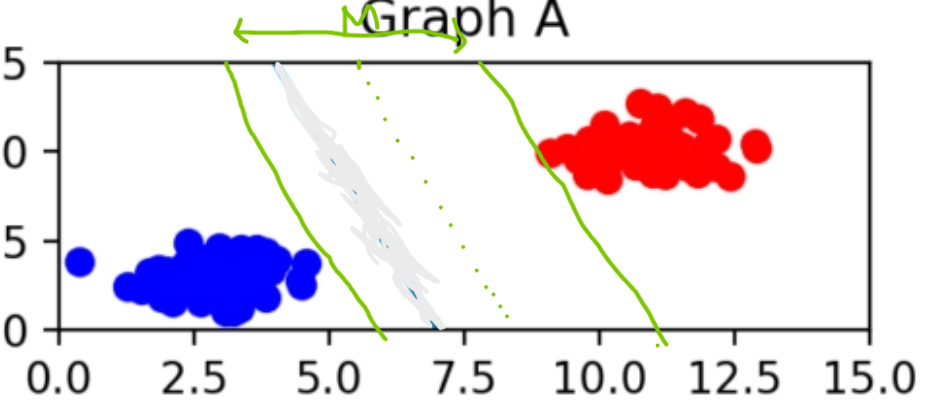
**장단점**
| 장점 | 단점 |
| --- | --- |
| 서포트 벡터만 이용해 결정 경계를 생성하므로 데이터가 적을 때 효과적 | 데이터 전처리 과정이 중요 |
| 새 데이터 입력 시 서포트 벡터와의 거리만 계산 → 연산량 최소화 | 데이터가 많아질수록 최적화 평가 과정이 늘어 속도가 느림 |
| 정확성이 뛰어나며 비선형 모델 분류 가능(커널 사용시) | |
| 마진 최대화 방식이 규제 역할을 하고 노이즈 영향이 적음 | |

## (4) KNN 

가정:  비슷한 특성을 가진 데이터끼리 서로 가까이 있다는 점을 이용.

> 데이터로부터 거리가 가까운 K개의 다른 데이터 레이블을 참조하여 분류하는 알고리즘

순서
1. 데이터 준비: 미리 학습하는 과정이 없어, 특징 벡터+레이블로 구성된 데이터만 준비
2. K 값 설정: 가장 가까운 이웃의 개수. 동점 방지를 위해 보통 홀수로 설정
3. 거리 계산: 새 데이터와 기존 모든 데이터 간 거리 계산 (유클리드, 맨해튼 거리 등)
4. 가장 가까운 K개의 이웃 선택
5. 분류: K개 이웃 중 가장 많이 등장하는 클래스가 예측 결과

**최적의 K 선택법**: 보통 학습 데이터 개수의 제곱근으로 설정함. K가 너무 크면 근접성이 떨어져 과소적합, 너무 작으면 이상값·잡음과 이웃이 될 가능성 있음.

특징: **별도의 학습이 필요 없음** 군집개수는 미리정해야함.

**장단점**
| 장점 | 단점 |
| --- | --- |
| 범주 기준을 몰라도 분류 가능 | 테스트 데이터 개수에 따라 시간이 오래 걸림 |
| 학습 과정 필요 없이 바로 예측값 도출 | 학습 데이터 양이 계산 시간에 영향 |
| 이해가 쉽고 구현이 간단 | K값 결정이 어려움 |
| 추가 데이터 처리 용이 | 수치형 데이터가 아니면 유사도 정의가 어려움 |
| 원본 데이터 전체를 그대로 저장(요약·일반화 안 함) | 이상치가 있으면 분류 성능에 큰 영향 |


**장단점**
| 장점 | 단점 |
| --- | --- |
| 서포트 벡터만 이용해 결정 경계를 생성하므로 데이터가 적을 때 효과적 | 데이터 전처리 과정이 중요 |
| 새 데이터 입력 시 서포트 벡터와의 거리만 계산 → 연산량 최소화 | 데이터가 많아질수록 최적화 평가 과정이 늘어 속도가 느림 |
| 정확성이 뛰어나며 비선형 모델 분류 가능(커널 사용시) | |
| 마진 최대화 방식이 규제 역할을 하고 노이즈 영향이 적음 | |

## (4) KNN 

가정:  비슷한 특성을 가진 데이터끼리 서로 가까이 있다는 점을 이용.

> 데이터로부터 거리가 가까운 K개의 다른 데이터 레이블을 참조하여 분류하는 알고리즘

순서
1. 데이터 준비: 미리 학습하는 과정이 없어, 특징 벡터+레이블로 구성된 데이터만 준비
2. K 값 설정: 가장 가까운 이웃의 개수. 동점 방지를 위해 보통 홀수로 설정
3. 거리 계산: 새 데이터와 기존 모든 데이터 간 거리 계산 (유클리드, 맨해튼 거리 등)
4. 가장 가까운 K개의 이웃 선택
5. 분류: K개 이웃 중 가장 많이 등장하는 클래스가 예측 결과

**최적의 K 선택법**: 보통 학습 데이터 개수의 제곱근으로 설정함. K가 너무 크면 근접성이 떨어져 과소적합, 너무 작으면 이상값·잡음과 이웃이 될 가능성 있음.

특징: **별도의 학습이 필요 없음** 군집개수는 미리정해야함.

**장단점**
| 장점 | 단점 |
| --- | --- |
| 범주 기준을 몰라도 분류 가능 | 테스트 데이터 개수에 따라 시간이 오래 걸림 |
| 학습 과정 필요 없이 바로 예측값 도출 | 학습 데이터 양이 계산 시간에 영향 |
| 이해가 쉽고 구현이 간단 | K값 결정이 어려움 |
| 추가 데이터 처리 용이 | 수치형 데이터가 아니면 유사도 정의가 어려움 |
| 원본 데이터 전체를 그대로 저장(요약·일반화 안 함) | 이상치가 있으면 분류 성능에 큰 영향 |



##  앙상블 

여러 개의 개별 분류 모델들을 결합해 하나의 분류 모델보다 더 좋은 성능을 내는 머신러닝 기법. 

**앙상블의 종류**
1. **보팅(Voting)**: 소프트보팅/하드보팅(우리가 아는 투표)이 있음. 하나 뽑는것
2. **배깅(Bagging)**: 학습데이터에서 여러표본을 뽑아 각각 학습을 시킴. 그중 하나를 보팅함.
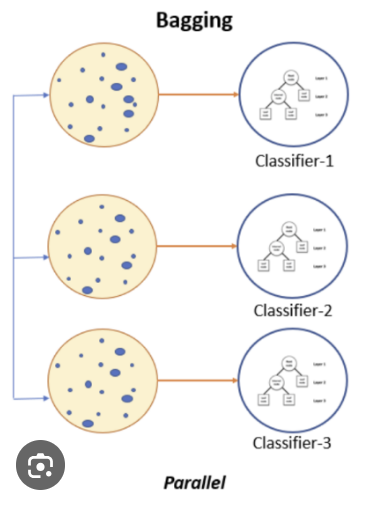
3. **부스팅(Boosting)**:  약분류기부터 ***직렬로 순차적으로(데이터시험 단골임니다..)*** 학습시켜서 강분류기로 만듦. 시간이오래걸림.
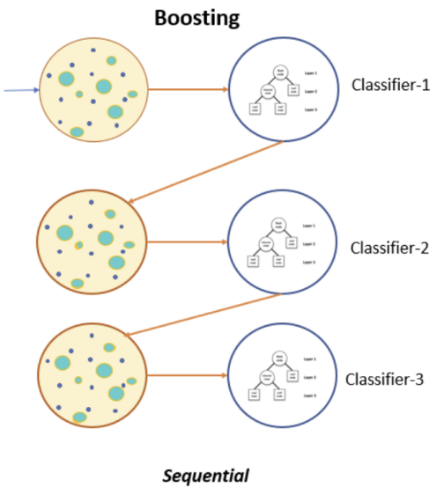